In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import joblib
#import yfinance as yf
import pickle
import matplotlib.pyplot as plt

In [3]:
try:
    from src.config import DATA_RAW_DIR
    print("All imports and 'src' package paths loaded successfully!")
except ModuleNotFoundError as e:
    print(f"Path Configuration Error: Could not locate 'src' package from {project_root}. Details: {e}")

file_path = DATA_RAW_DIR / "Bitcoin Historical Data.csv"
df = pd.read_csv(file_path)

All imports and 'src' package paths loaded successfully!


In [4]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


In [5]:
df.shape

(4999, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      4999 non-null   str  
 1   Price     4999 non-null   str  
 2   Open      4999 non-null   str  
 3   High      4999 non-null   str  
 4   Low       4999 non-null   str  
 5   Vol.      4993 non-null   str  
 6   Change %  4999 non-null   str  
dtypes: str(7)
memory usage: 497.2 KB


In [7]:
df_univariate = df[['Date', 'Price']].copy()

df_univariate['Date'] = pd.to_datetime(df_univariate['Date'], format='%d-%m-%Y')
df_univariate['Price'] = df_univariate['Price'].astype(str).str.replace(',', '')
df_univariate['Price'] = pd.to_numeric(df_univariate['Price'], errors='coerce')

df_univariate = df_univariate.sort_values('Date').reset_index(drop=True)

df_univariate.head(3)

,Date,Price
0,2010-07-18,0.1
1,2010-07-19,0.1
2,2010-07-20,0.1


In [8]:
df_univariate.tail(3)

,Date,Price
4996,2024-03-22,63785.5
4997,2024-03-23,64037.8
4998,2024-03-24,67211.9


#### Splitting Train, Test

In [9]:
split_idx = int(len(df_univariate) * 0.80)

train_df = df_univariate.iloc[:split_idx].copy()
test_df = df_univariate.iloc[split_idx:].copy()

print(f"Training set shapes: {train_df.shape} (Dates: {train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Testing set shapes:  {test_df.shape} (Dates: {test_df['Date'].min()} to {test_df['Date'].max()})")

Training set shapes: (3999, 2) (Dates: 2010-07-18 00:00:00 to 2021-06-28 00:00:00)
Testing set shapes:  (1000, 2) (Dates: 2021-06-29 00:00:00 to 2024-03-24 00:00:00)


#### Feature Scaling : MinMax Scaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

y_train_raw = train_df[['Price']].values
y_test_raw = test_df[['Price']].values

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(y_train_raw)
test_scaled = scaler.transform(y_test_raw)

print("Data successfully scaled using Min Max Scaler.")


Data successfully scaled using Min Max Scaler.


In [73]:
import pickle

scaler_path = os.path.join('models', 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler successfully saved as a clean binary pickle file!")

Scaler successfully saved as a clean binary pickle file!


#### Sequence Generation

In [11]:
import numpy as np

def create_sliding_windows(data_array, lookback=60, horizon=1):
    
    X, y = [], []
    
    upper_bound = len(data_array) - lookback - horizon + 1
    
    for i in range(upper_bound):
        window = data_array[i : i + lookback]
        target = data_array[i + lookback : i + lookback + horizon]
        
        X.append(window)
        y.append(target.flatten())
        
    return np.array(X), np.array(y)

In [12]:
LOOKBACK = 60

# 1-Day Horizon (1D)
X_train_1d, y_train_1d = create_sliding_windows(train_scaled, lookback=LOOKBACK, horizon=1)
X_test_1d, y_test_1d = create_sliding_windows(test_scaled, lookback=LOOKBACK, horizon=1)

# 3-Day Horizon (3D)
X_train_3d, y_train_3d = create_sliding_windows(train_scaled, lookback=LOOKBACK, horizon=3)
X_test_3d, y_test_3d = create_sliding_windows(test_scaled, lookback=LOOKBACK, horizon=3)

# 7-Day Horizon (7D)
X_train_7d, y_train_7d = create_sliding_windows(train_scaled, lookback=LOOKBACK, horizon=7)
X_test_7d, y_test_7d = create_sliding_windows(test_scaled, lookback=LOOKBACK, horizon=7)

# Verify the matrix shapes match our mathematical expectations
print("1D Horizon Shapes")
print(f"X_train_1d: {X_train_1d.shape} | y_train_1d: {y_train_1d.shape}")
print(f"X_test_1d : {X_test_1d.shape}  | y_test_1d : {y_test_1d.shape}\n")

print("3D Horizon Shapes")
print(f"X_train_3d: {X_train_3d.shape} | y_train_3d: {y_train_3d.shape}")
print(f"X_test_3d : {X_test_3d.shape}  | y_test_3d : {y_test_3d.shape}\n")

print("7D Horizon Shapes")
print(f"X_train_7d: {X_train_7d.shape} | y_train_7d: {y_train_7d.shape}")
print(f"X_test_7d : {X_test_7d.shape}  | y_test_7d : {y_test_7d.shape}")

1D Horizon Shapes
X_train_1d: (3939, 60, 1) | y_train_1d: (3939, 1)
X_test_1d : (940, 60, 1)  | y_test_1d : (940, 1)

3D Horizon Shapes
X_train_3d: (3937, 60, 1) | y_train_3d: (3937, 3)
X_test_3d : (938, 60, 1)  | y_test_3d : (938, 3)

7D Horizon Shapes
X_train_7d: (3933, 60, 1) | y_train_7d: (3933, 7)
X_test_7d : (934, 60, 1)  | y_test_7d : (934, 7)


#### Deep Learning Models

#### RNN

In [13]:
def build_rnn_model(lookback=60, features=1, horizon=1):
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.SimpleRNN(64, activation='tanh', return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

rnn_1d = build_rnn_model(horizon=1)
history_rnn_1d = rnn_1d.fit(
    X_train_1d, y_train_1d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_1d, y_test_1d),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.1634e-04 - val_loss: 0.0014
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.1957e-04 - val_loss: 0.0045
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.8515e-04 - val_loss: 8.1015e-04
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2786e-04 - val_loss: 8.1164e-04
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.7121e-04 - val_loss: 7.0607e-04
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.9014e-04 - val_loss: 6.0155e-04
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.0083e-04 - val_loss: 8.7418e-04
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3326e-04 - val_loss: 6.0922e-04
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.6251e-04 - val_loss: 7.9639e-04
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.5922e-0

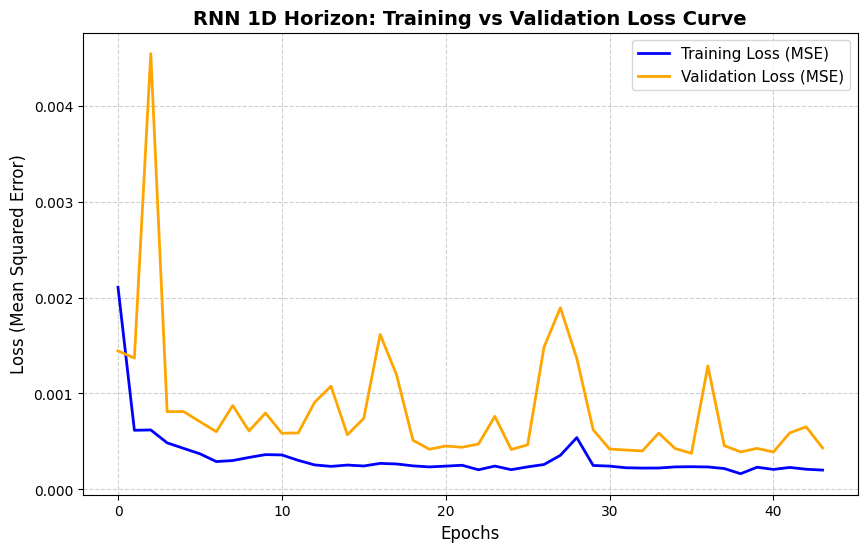

Training process concluded naturally at epoch 44.


In [15]:
plt.figure(figsize=(10, 6))

plt.plot(history_rnn_1d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_rnn_1d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('RNN 1D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded naturally at epoch {len(history_rnn_1d.history['loss'])}.")

In [16]:
rnn_1d_preds = rnn_1d.predict(X_test_1d, verbose=0)

y_actual_1d_usd = scaler.inverse_transform(y_test_1d)
preds_1d_usd = scaler.inverse_transform(rnn_1d_preds)

mae_1d = mean_absolute_error(y_actual_1d_usd, preds_1d_usd)
rmse_1d = np.sqrt(mean_squared_error(y_actual_1d_usd, preds_1d_usd))
mape_1d = mean_absolute_percentage_error(y_actual_1d_usd, preds_1d_usd) * 100

print("="*50)
print("           RNN 1-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_1d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_1d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_1d:.2f}%")
print("="*50)

           RNN 1-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $822.73 USD
Root Mean Squared Error (RMSE) : $1232.06 USD
Mean Absolute Percentage (MAPE): 2.40%


In [17]:
os.makedirs('models/histories', exist_ok=True)
rnn_1d.save('models/rnn_1d_model.keras')

with open('models/histories/rnn_1d_history.pkl', 'wb') as f:
    pickle.dump(history_rnn_1d.history, f)

print("RNN 1D Model and training history saved successfully!")

RNN 1D Model and training history saved successfully!


#### RNN 3D

In [18]:
rnn_3d = build_rnn_model(horizon=3)
history_rnn_3d = rnn_3d.fit(
    X_train_3d, y_train_3d,
    epochs=18,
    batch_size=32,
    validation_data=(X_test_3d, y_test_3d),
    verbose=1
)

Epoch 1/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 2/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 3/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7067e-04 - val_loss: 0.0022
Epoch 4/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.2945e-04 - val_loss: 9.4704e-04
Epoch 5/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.8951e-04 - val_loss: 0.0011
Epoch 6/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.0316e-04 - val_loss: 8.4729e-04
Epoch 7/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5698e-04 - val_loss: 0.0014
Epoch 8/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6778e-04 - val_loss: 0.0013
Epoch 9/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.2696e-04 - val_loss: 0.0073
Epoch 10/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.3738e-04 - val_loss: 7.8211e-04
Epoch 11/18
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0137e-04 - val_loss: 0.0045


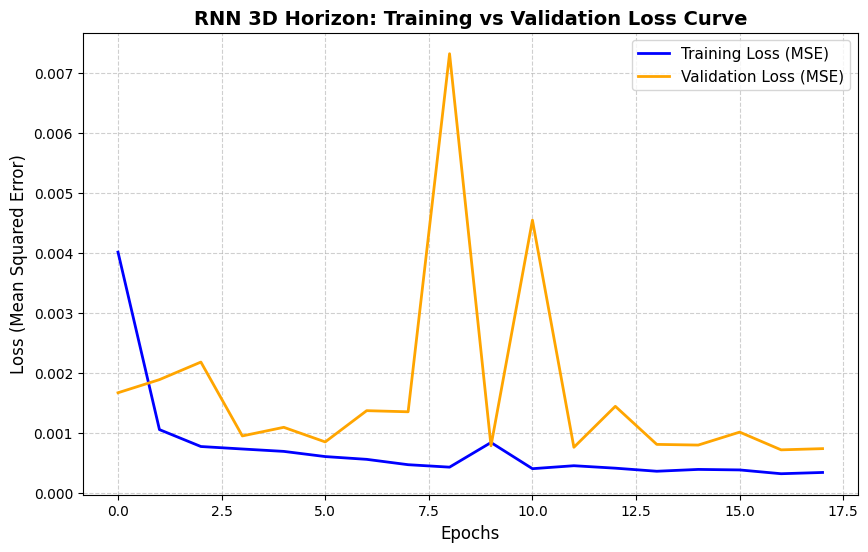

Training process concluded at epoch 18.


In [19]:
plt.figure(figsize=(10, 6))

plt.plot(history_rnn_3d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_rnn_3d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('RNN 3D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded at epoch {len(history_rnn_3d.history['loss'])}.")

In [20]:
rnn_3d_preds = rnn_3d.predict(X_test_3d, verbose=0)

y_actual_3d_usd = scaler.inverse_transform(y_test_3d)
preds_3d_usd = scaler.inverse_transform(rnn_3d_preds)

mae_3d = mean_absolute_error(y_actual_3d_usd, preds_3d_usd)
rmse_3d = np.sqrt(mean_squared_error(y_actual_3d_usd, preds_3d_usd))
mape_3d = mean_absolute_percentage_error(y_actual_3d_usd, preds_3d_usd) * 100

print("="*50)
print("           RNN 3-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_3d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_3d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_3d:.2f}%")
print("="*50)

           RNN 3-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1169.31 USD
Root Mean Squared Error (RMSE) : $1723.09 USD
Mean Absolute Percentage (MAPE): 3.42%


In [21]:
rnn_3d.save('models/rnn_3d_model.keras')

with open('models/histories/rnn_3d_history.pkl', 'wb') as f:
    pickle.dump(history_rnn_3d.history, f)

print("RNN 3D Model and training history saved successfully!")

RNN 3D Model and training history saved successfully!


#### RNN 7D

In [22]:
early_stopping_7d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

rnn_7d = build_rnn_model(horizon=7)

history_rnn_7d = rnn_7d.fit(
    X_train_7d, y_train_7d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_7d, y_test_7d),
    callbacks=[early_stopping_7d],
    verbose=1
)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0066 - val_loss: 0.0033
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.7894e-04 - val_loss: 0.0019
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.5465e-04 - val_loss: 0.0021
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5046e-04 - val_loss: 0.0016
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.8830e-04 - val_loss: 0.0015
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.8229e-04 - val_loss: 0.0017
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.9405e-04 - val_loss: 0.0016
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.2005e-04 - val_loss: 0.0018
Epoch 12/50
123/123 ━━

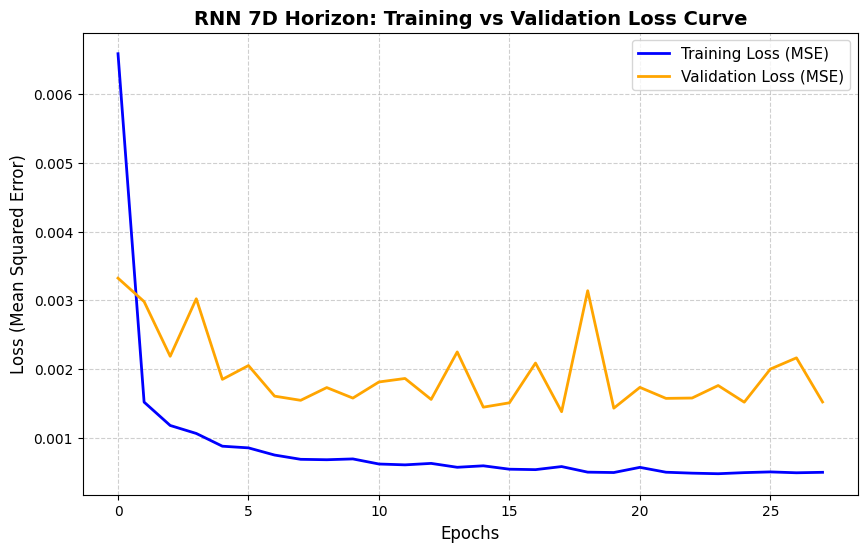

Training process concluded at epoch 28.


In [23]:
plt.figure(figsize=(10, 6))

plt.plot(history_rnn_7d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_rnn_7d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('RNN 7D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded at epoch {len(history_rnn_7d.history['loss'])}.")

In [24]:
rnn_7d_preds = rnn_7d.predict(X_test_7d, verbose=0)

y_actual_7d_usd = scaler.inverse_transform(y_test_7d)
preds_7d_usd = scaler.inverse_transform(rnn_7d_preds)

mae_7d = mean_absolute_error(y_actual_7d_usd, preds_7d_usd)
rmse_7d = np.sqrt(mean_squared_error(y_actual_7d_usd, preds_7d_usd))
mape_7d = mean_absolute_percentage_error(y_actual_7d_usd, preds_7d_usd) * 100

print("="*50)
print("           RNN 7-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_7d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_7d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_7d:.2f}%")
print("="*50)

           RNN 7-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1565.79 USD
Root Mean Squared Error (RMSE) : $2360.62 USD
Mean Absolute Percentage (MAPE): 4.54%


In [25]:
rnn_7d.save('models/rnn_7d_model.keras')

with open('models/histories/rnn_7d_history.pkl', 'wb') as f:
    pickle.dump(history_rnn_7d.history, f)

print("RNN 7D Model and training history saved successfully!")

RNN 7D Model and training history saved successfully!


#### LSTM 

In [26]:
def build_lstm_model(lookback=60, features=1, horizon=1):
    
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.LSTM(64, activation='tanh', return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(horizon)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

In [27]:
early_stopping_lstm_1d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lstm_1d = build_lstm_model(horizon=1)

history_lstm_1d = lstm_1d.fit(
    X_train_1d, y_train_1d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_1d, y_test_1d),
    callbacks=[early_stopping_lstm_1d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 7.4727e-04 - val_loss: 0.0019
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.0722e-04 - val_loss: 0.0014
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 4.6894e-04 - val_loss: 0.0010
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 4.3459e-04 - val_loss: 0.0011
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 4.3605e-04 - val_loss: 8.7435e-04
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 3.9490e-04 - val_loss: 0.0020
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 3.6587e-04 - val_loss: 0.0015
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.6640e-04 - val_loss: 9.4762e-04
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 2.9094e-04 - val_loss: 0.0015
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5.9630e-04 - val_loss: 

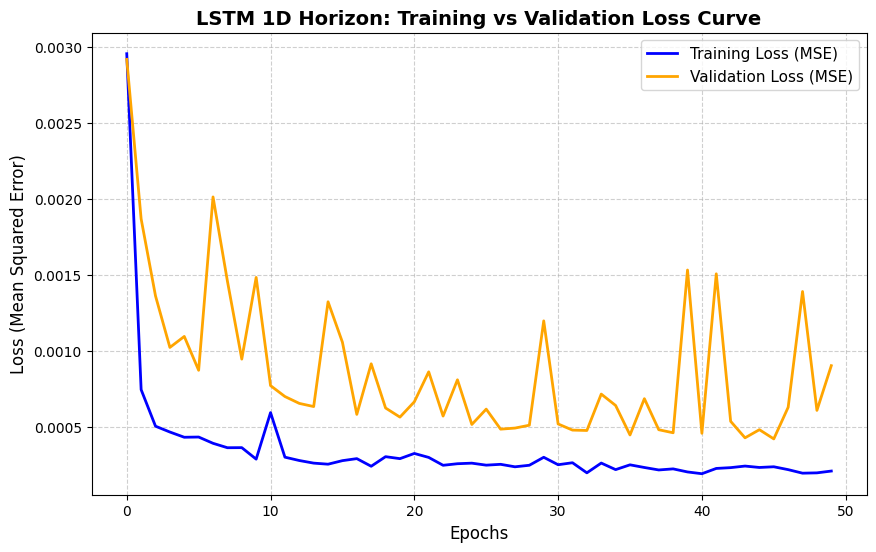

Training process concluded at epoch 50.


In [28]:
plt.figure(figsize=(10, 6))

plt.plot(history_lstm_1d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_lstm_1d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('LSTM 1D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Training process concluded at epoch {len(history_lstm_1d.history['loss'])}.")

In [29]:
lstm_1d_preds = lstm_1d.predict(X_test_1d, verbose=0)

y_actual_lstm_1d_usd = scaler.inverse_transform(y_test_1d)
preds_lstm_1d_usd = scaler.inverse_transform(lstm_1d_preds)

mae_lstm_1d = mean_absolute_error(y_actual_lstm_1d_usd, preds_lstm_1d_usd)
rmse_lstm_1d = np.sqrt(mean_squared_error(y_actual_lstm_1d_usd, preds_lstm_1d_usd))
mape_lstm_1d = mean_absolute_percentage_error(y_actual_lstm_1d_usd, preds_lstm_1d_usd) * 100

print("="*50)
print("           LSTM 1-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_lstm_1d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_lstm_1d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_lstm_1d:.2f}%")
print("="*50)

           LSTM 1-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $862.08 USD
Root Mean Squared Error (RMSE) : $1308.02 USD
Mean Absolute Percentage (MAPE): 2.46%


In [30]:

lstm_1d.save('models/lstm_1d_model.keras')

with open('models/histories/lstm_1d_history.pkl', 'wb') as f:
    pickle.dump(history_lstm_1d.history, f)

print("LSTM 1D Model and training history saved successfully!")

LSTM 1D Model and training history saved successfully!


#### LSTM 3D

In [31]:
early_stopping_lstm_3d = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lstm_3d = build_lstm_model(horizon=3)

history_lstm_3d = lstm_3d.fit(
    X_train_3d, y_train_3d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_3d, y_test_3d),
    callbacks=[early_stopping_lstm_3d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 9.8226e-04 - val_loss: 0.0030
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.5897e-04 - val_loss: 0.0020
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.9739e-04 - val_loss: 0.0015
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.6902e-04 - val_loss: 0.0014
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 4.8068e-04 - val_loss: 0.0013
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.4355e-04 - val_loss: 0.0012
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 4.3990e-04 - val_loss: 0.0016
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 4.9298e-04 - val_loss: 0.0013
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 4.5288e-04 - val_loss: 0.0011
Epoch

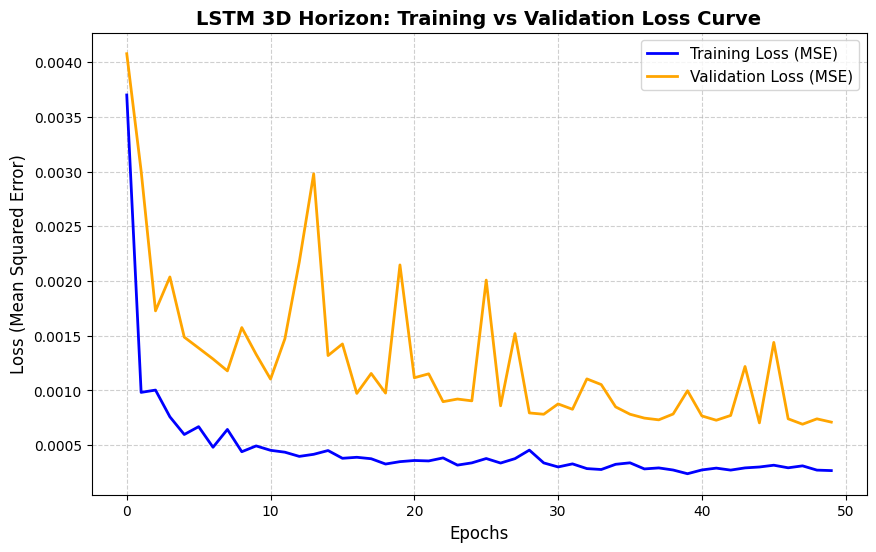

Training process concluded naturally at epoch 50.


In [32]:
plt.figure(figsize=(10, 6))

plt.plot(history_lstm_3d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_lstm_3d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('LSTM 3D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded naturally at epoch {len(history_lstm_3d.history['loss'])}.")

In [33]:
lstm_3d_preds = lstm_3d.predict(X_test_3d, verbose=0)

y_actual_lstm_3d_usd = scaler.inverse_transform(y_test_3d)
preds_lstm_3d_usd = scaler.inverse_transform(lstm_3d_preds)

mae_lstm_3d = mean_absolute_error(y_actual_lstm_3d_usd, preds_lstm_3d_usd)
rmse_lstm_3d = np.sqrt(mean_squared_error(y_actual_lstm_3d_usd, preds_lstm_3d_usd))
mape_lstm_3d = mean_absolute_percentage_error(y_actual_lstm_3d_usd, preds_lstm_3d_usd) * 100

print("="*50)
print("           LSTM 3-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_lstm_3d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_lstm_3d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_lstm_3d:.2f}%")
print("="*50)

           LSTM 3-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1112.23 USD
Root Mean Squared Error (RMSE) : $1670.67 USD
Mean Absolute Percentage (MAPE): 3.25%


In [34]:
lstm_3d.save('models/lstm_3d_model.keras')

# 3. Save the training history log to disk using pickle
with open('models/histories/lstm_3d_history.pkl', 'wb') as f:
    pickle.dump(history_lstm_3d.history, f)

print("LSTM 3D Model and training history saved successfully!")

LSTM 3D Model and training history saved successfully!


#### LSTM 7D

In [35]:
early_stopping_lstm_7d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lstm_7d = build_lstm_model(horizon=7)

history_lstm_7d = lstm_7d.fit(
    X_train_7d, y_train_7d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_7d, y_test_7d),
    callbacks=[early_stopping_lstm_7d],
    verbose=1
)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 9.6765e-04 - val_loss: 0.0030
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 9.8142e-04 - val_loss: 0.0023
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.6154e-04 - val_loss: 0.0025
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.0135e-04 - val_loss: 0.0032
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.7404e-04 - val_loss: 0.0021
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.1394e-04 - val_loss: 0.0019
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.3631e-04 - val_loss: 0.0034
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 6.2111e-04 - val_loss: 0.0030
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.3771e-04 - val_loss: 0.0020
Epoch

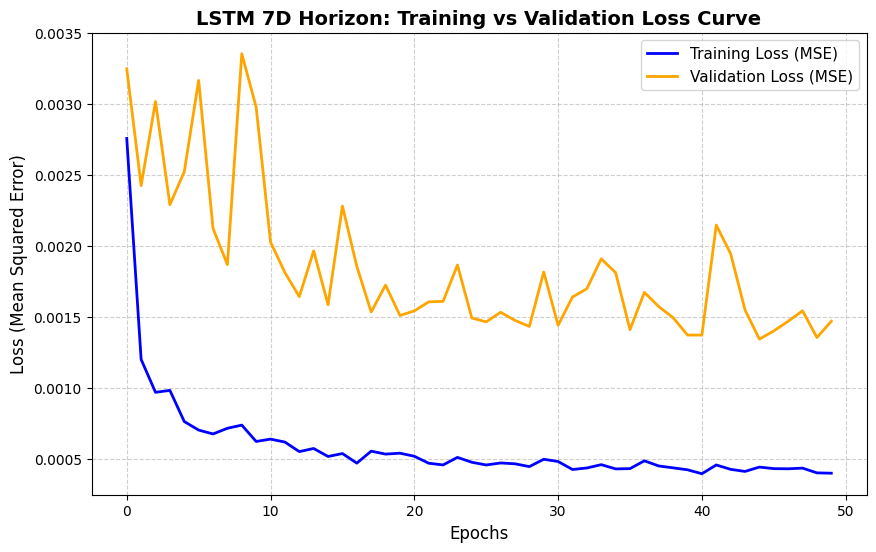

Training process concluded naturally at epoch 50.


In [36]:
plt.figure(figsize=(10, 6))

plt.plot(history_lstm_7d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_lstm_7d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('LSTM 7D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Training process concluded naturally at epoch {len(history_lstm_7d.history['loss'])}.")

In [37]:
# 1. Generate predictions on the 7D test set
lstm_7d_preds = lstm_7d.predict(X_test_7d, verbose=0)

# 2. Inverse-transform predictions and actual targets back to original USD values
y_actual_lstm_7d_usd = scaler.inverse_transform(y_test_7d)
preds_lstm_7d_usd = scaler.inverse_transform(lstm_7d_preds)

# 3. Calculate metrics across all 7 days simultaneously
mae_lstm_7d = mean_absolute_error(y_actual_lstm_7d_usd, preds_lstm_7d_usd)
rmse_lstm_7d = np.sqrt(mean_squared_error(y_actual_lstm_7d_usd, preds_lstm_7d_usd))
mape_lstm_7d = mean_absolute_percentage_error(y_actual_lstm_7d_usd, preds_lstm_7d_usd) * 100

# 4. Print the performance summary
print("="*50)
print("           LSTM 7-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_lstm_7d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_lstm_7d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_lstm_7d:.2f}%")
print("="*50)

           LSTM 7-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1549.13 USD
Root Mean Squared Error (RMSE) : $2328.29 USD
Mean Absolute Percentage (MAPE): 4.53%


In [38]:
lstm_7d.save('models/lstm_7d_model.keras')

with open('models/histories/lstm_7d_history.pkl', 'wb') as f:
    pickle.dump(history_lstm_7d.history, f)

print("LSTM 7D Model and training history saved successfully!")

LSTM 7D Model and training history saved successfully!


#### CNN-1D

In [39]:
def build_cnn_model(lookback=60, features=1, horizon=1):
    
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(50, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(horizon)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

##### CNN-1D : 1D

In [40]:
early_stopping_cnn_1d = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

cnn_1d = build_cnn_model(horizon=1)

history_cnn_1d = cnn_1d.fit(
    X_train_1d, y_train_1d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_1d, y_test_1d),
    callbacks=[early_stopping_cnn_1d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.2520e-04 - val_loss: 0.0013
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.4399e-04 - val_loss: 0.0045
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.3044e-04 - val_loss: 0.0041
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.9725e-04 - val_loss: 0.0018
Epoch 12/50
124/124 ━━━━━━━━━━━━━━━━

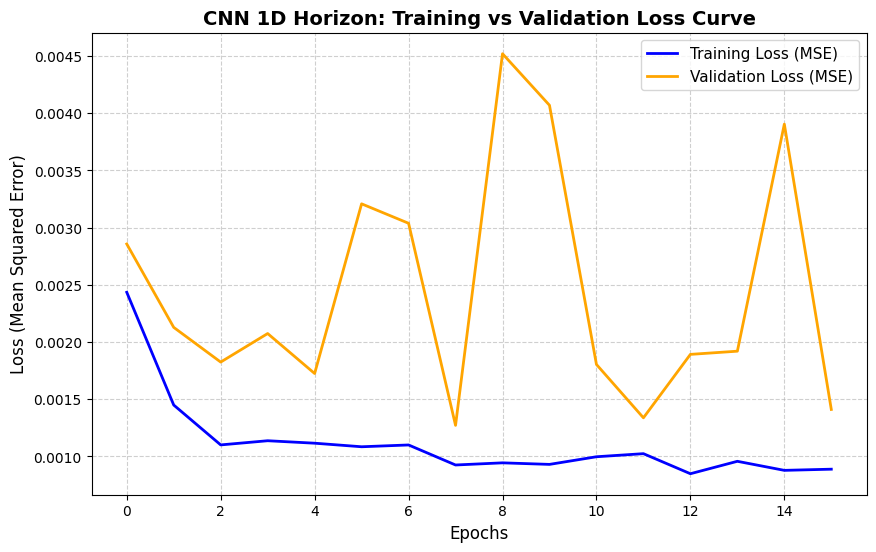

Training process concluded at epoch 16.


In [41]:
plt.figure(figsize=(10, 6))

plt.plot(history_cnn_1d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_cnn_1d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('CNN 1D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded at epoch {len(history_cnn_1d.history['loss'])}.")

In [42]:
cnn_1d_preds = cnn_1d.predict(X_test_1d, verbose=0)

y_actual_cnn_1d_usd = scaler.inverse_transform(y_test_1d)
preds_cnn_1d_usd = scaler.inverse_transform(cnn_1d_preds)

mae_cnn_1d = mean_absolute_error(y_actual_cnn_1d_usd, preds_cnn_1d_usd)
rmse_cnn_1d = np.sqrt(mean_squared_error(y_actual_cnn_1d_usd, preds_cnn_1d_usd))
mape_cnn_1d = mean_absolute_percentage_error(y_actual_cnn_1d_usd, preds_cnn_1d_usd) * 100

print("="*50)
print("           CNN 1-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_cnn_1d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_cnn_1d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_cnn_1d:.2f}%")
print("="*50)

           CNN 1-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1593.65 USD
Root Mean Squared Error (RMSE) : $2265.92 USD
Mean Absolute Percentage (MAPE): 4.59%


In [43]:
cnn_1d.save('models/cnn_1d_model.keras')

with open('models/histories/cnn_1d_history.pkl', 'wb') as f:
    pickle.dump(history_cnn_1d.history, f)

print("CNN 1D Model and training history saved successfully!")

CNN 1D Model and training history saved successfully!


#### CNN 3D

In [44]:
early_stopping_cnn_3d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_3d = build_cnn_model(horizon=3)

history_cnn_3d = cnn_3d.fit(
    X_train_3d, y_train_3d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_3d, y_test_3d),
    callbacks=[early_stopping_cnn_3d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0036 - val_loss: 0.0106
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016 - val_loss: 0.0055
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0052
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 0.0050
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 0.0054
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010 - val_loss: 0.0065
Epoch 12/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

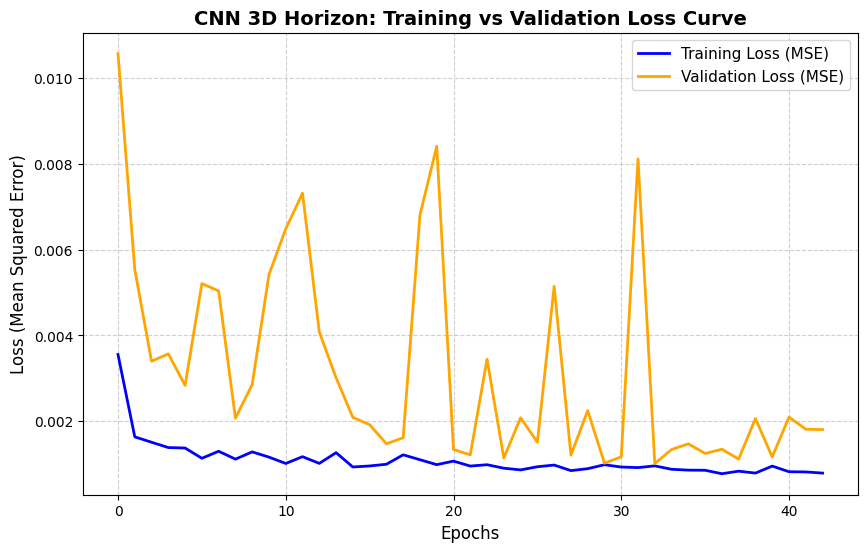

Training process concluded at epoch 43.


In [45]:
plt.figure(figsize=(10, 6))

plt.plot(history_cnn_3d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_cnn_3d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('CNN 3D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Training process concluded at epoch {len(history_cnn_3d.history['loss'])}.")

In [46]:
cnn_3d_preds = cnn_3d.predict(X_test_3d, verbose=0)

y_actual_cnn_3d_usd = scaler.inverse_transform(y_test_3d)
preds_cnn_3d_usd = scaler.inverse_transform(cnn_3d_preds)

mae_cnn_3d = mean_absolute_error(y_actual_cnn_3d_usd, preds_cnn_3d_usd)
rmse_cnn_3d = np.sqrt(mean_squared_error(y_actual_cnn_3d_usd, preds_cnn_3d_usd))
mape_cnn_3d = mean_absolute_percentage_error(y_actual_cnn_3d_usd, preds_cnn_3d_usd) * 100

print("="*50)
print("           CNN 3-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_cnn_3d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_cnn_3d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_cnn_3d:.2f}%")
print("="*50)

           CNN 3-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $1392.54 USD
Root Mean Squared Error (RMSE) : $2018.39 USD
Mean Absolute Percentage (MAPE): 4.09%


In [47]:
cnn_3d.save('models/cnn_3d_model.keras')

with open('models/histories/cnn_3d_history.pkl', 'wb') as f:
    pickle.dump(history_cnn_3d.history, f)

print("CNN 3D Model and training history saved successfully!")

CNN 3D Model and training history saved successfully!


#### CNN 7D

In [48]:
early_stopping_cnn_7d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_7d = build_cnn_model(horizon=7)

history_cnn_7d = cnn_7d.fit(
    X_train_7d, y_train_7d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_7d, y_test_7d),
    callbacks=[early_stopping_cnn_7d],
    verbose=1
)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - val_loss: 0.0091
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0026 - val_loss: 0.0078
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0021 - val_loss: 0.0054
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019 - val_loss: 0.0048
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 0.0053
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - val_loss: 0.0108
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0014 - val_loss: 0.0105
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018 - val_loss: 0.0049
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - val_loss: 0.0031
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 0.0053
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

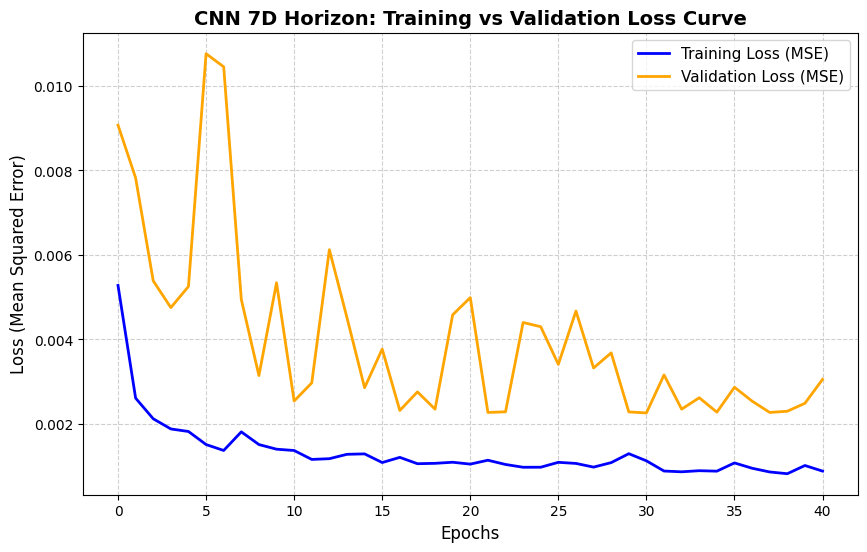

Training process concluded naturally at epoch 41.


In [49]:
plt.figure(figsize=(10, 6))

plt.plot(history_cnn_7d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_cnn_7d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('CNN 7D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded naturally at epoch {len(history_cnn_7d.history['loss'])}.")

In [50]:
cnn_7d_preds = cnn_7d.predict(X_test_7d, verbose=0)

y_actual_cnn_7d_usd = scaler.inverse_transform(y_test_7d)
preds_cnn_7d_usd = scaler.inverse_transform(cnn_7d_preds)

mae_cnn_7d = mean_absolute_error(y_actual_cnn_7d_usd, preds_cnn_7d_usd)
rmse_cnn_7d = np.sqrt(mean_squared_error(y_actual_cnn_7d_usd, preds_cnn_7d_usd))
mape_cnn_7d = mean_absolute_percentage_error(y_actual_cnn_7d_usd, preds_cnn_7d_usd) * 100

print("="*50)
print("           CNN 7-DAY HORIZON PERFORMANCE            ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_cnn_7d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_cnn_7d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_cnn_7d:.2f}%")
print("="*50)

           CNN 7-DAY HORIZON PERFORMANCE            
Mean Absolute Error (MAE)      : $2116.36 USD
Root Mean Squared Error (RMSE) : $3021.93 USD
Mean Absolute Percentage (MAPE): 6.21%


In [51]:
cnn_7d.save('models/cnn_7d_model.keras')

with open('models/histories/cnn_7d_history.pkl', 'wb') as f:
    pickle.dump(history_cnn_7d.history, f)

print("CNN 7D Model and training history saved successfully!")

CNN 7D Model and training history saved successfully!


#### Transformer

In [52]:
def build_transformer_model(lookback=60, features=1, horizon=1):
    """
    Stabilized Time-Series Transformer Network optimized for single-feature input.
    """
    inputs = layers.Input(shape=(lookback, features))
    
    # 1. Project single-feature price into a higher-dimensional space
    # This prevents LayerNorm from collapsing and gives attention channels to work with
    x = layers.Conv1D(filters=32, kernel_size=1, activation='relu')(inputs)
    
    # 2. Multi-Head Attention layer
    attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attention_out = layers.Dropout(0.1)(attention_out)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # 3. Position-wise Feed-Forward Network
    ffn_out = layers.Dense(64, activation='relu')(x)
    ffn_out = layers.Dense(32)(ffn_out) # Match the 32 channels
    ffn_out = layers.Dropout(0.1)(ffn_out)
    
    x = layers.Add()([x, ffn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # 4. Flatten and map directly to output horizon
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(horizon)(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # Compile with Adam optimizer
    model.compile(optimizer='adam', loss='mse')
    
    return model

In [53]:
# 1. Instantiate a dedicated early stopping rule for 1D Transformer
#early_stopping_trans_1d = EarlyStopping(
   # monitor='val_loss',
  #  patience=10,
 #   restore_best_weights=True
#)

In [54]:

# 2. Instantiate the 1D Transformer Model using our factory function
transformer_1d = build_transformer_model(horizon=1)

# 3. Train the model using the 1D training datasets
history_trans_1d = transformer_1d.fit(
    X_train_1d, y_train_1d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_1d, y_test_1d),
    #callbacks=[early_stopping_trans_1d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.3742 - val_loss: 0.0186
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0054 - val_loss: 0.0170
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0044 - val_loss: 0.0185
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0032 - val_loss: 0.0111
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0031 - val_loss: 0.0177
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0035 - val_loss: 0.0168
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0031 - val_loss: 0.0149
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0029 - val_loss: 0.0069
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0032 - val_loss: 0.0198
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0028 - val_loss: 0.0096
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0028 - val_loss: 0.0054
Epoch 12/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 

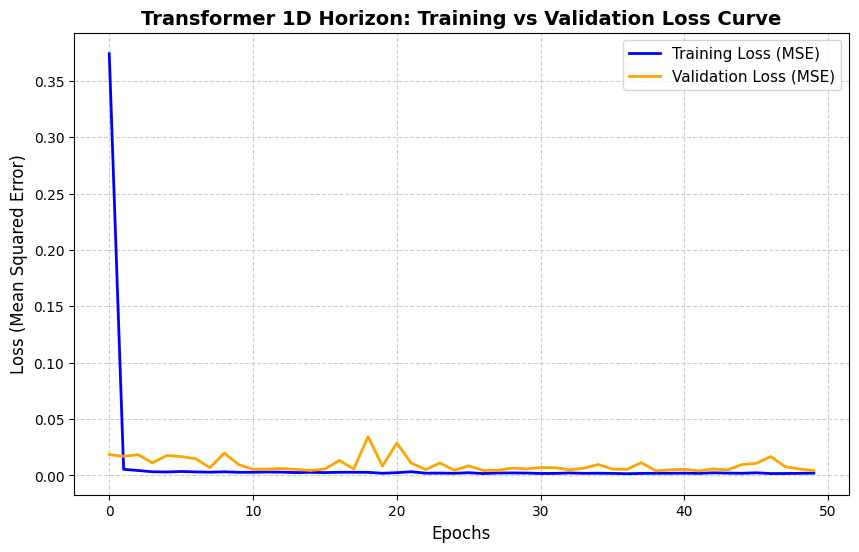

Training process concluded naturally at epoch 50.


In [55]:
# 1. Create a new figure and set its dimensions
plt.figure(figsize=(10, 6))

# 2. Plot the training and validation loss values from the history object
plt.plot(history_trans_1d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_trans_1d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

# 3. Add titles, labels, and formatting to the graph
plt.title('Transformer 1D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Display the plot cleanly
plt.show()

# 5. Print out the exact number of epochs executed before early stopping halted training
print(f"Training process concluded naturally at epoch {len(history_trans_1d.history['loss'])}.")

In [56]:
# 1. Generate predictions on the 1D test set
transformer_1d_preds = transformer_1d.predict(X_test_1d, verbose=0)

# 2. Inverse-transform predictions and actual targets back to original USD values
y_actual_trans_1d_usd = scaler.inverse_transform(y_test_1d)
preds_trans_1d_usd = scaler.inverse_transform(transformer_1d_preds)

# 3. Calculate metrics using scikit-learn functions
mae_trans_1d = mean_absolute_error(y_actual_trans_1d_usd, preds_trans_1d_usd)
rmse_trans_1d = np.sqrt(mean_squared_error(y_actual_trans_1d_usd, preds_trans_1d_usd))
mape_trans_1d = mean_absolute_percentage_error(y_actual_trans_1d_usd, preds_trans_1d_usd) * 100

# 4. Print the performance summary
print("="*50)
print("        TRANSFORMER 1-DAY HORIZON PERFORMANCE        ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_trans_1d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_trans_1d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_trans_1d:.2f}%")
print("="*50)

        TRANSFORMER 1-DAY HORIZON PERFORMANCE        
Mean Absolute Error (MAE)      : $2814.99 USD
Root Mean Squared Error (RMSE) : $4160.56 USD
Mean Absolute Percentage (MAPE): 7.87%


In [57]:
transformer_1d.save('models/transformer_1d_model.keras')

with open('models/histories/transformer_1d_history.pkl', 'wb') as f:
    pickle.dump(history_trans_1d.history, f)

print("Transformer 1D Model and training history saved successfully!")

Transformer 1D Model and training history saved successfully!


#### Transformer 3D

In [58]:
early_stopping_trans_3d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

transformer_3d = build_transformer_model(horizon=3)

history_trans_3d = transformer_3d.fit(
    X_train_3d, y_train_3d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_3d, y_test_3d),
    callbacks=[early_stopping_trans_3d],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.2572 - val_loss: 0.0288
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0082 - val_loss: 0.0148
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0071 - val_loss: 0.0100
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0064 - val_loss: 0.0130
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0060 - val_loss: 0.0124
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0046 - val_loss: 0.0110
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0055 - val_loss: 0.0131
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0048 - val_loss: 0.0179
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0042 - val_loss: 0.0095
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0039 - val_loss: 0.0117
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0046 - val_loss: 0.0105
Epoch 12/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 

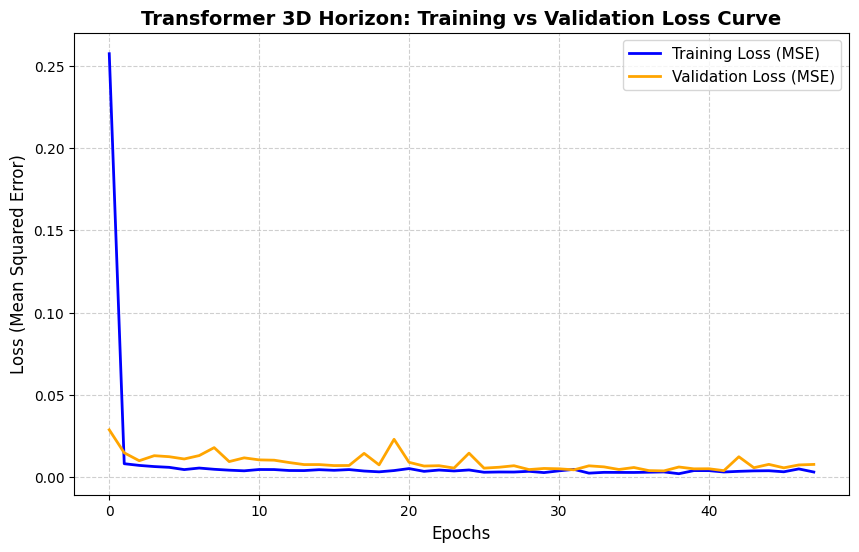

Training process concluded at epoch 48.


In [59]:
plt.figure(figsize=(10, 6))

plt.plot(history_trans_3d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_trans_3d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('Transformer 3D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded at epoch {len(history_trans_3d.history['loss'])}.")

In [60]:
transformer_3d_preds = transformer_3d.predict(X_test_3d, verbose=0)

y_actual_trans_3d_usd = scaler.inverse_transform(y_test_3d)
preds_trans_3d_usd = scaler.inverse_transform(transformer_3d_preds)

mae_trans_3d = mean_absolute_error(y_actual_trans_3d_usd, preds_trans_3d_usd)
rmse_trans_3d = np.sqrt(mean_squared_error(y_actual_trans_3d_usd, preds_trans_3d_usd))
mape_trans_3d = mean_absolute_percentage_error(y_actual_trans_3d_usd, preds_trans_3d_usd) * 100

print("="*50)
print("        TRANSFORMER 3-DAY HORIZON PERFORMANCE        ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_trans_3d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_trans_3d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_trans_3d:.2f}%")
print("="*50)

        TRANSFORMER 3-DAY HORIZON PERFORMANCE        
Mean Absolute Error (MAE)      : $2940.29 USD
Root Mean Squared Error (RMSE) : $3918.32 USD
Mean Absolute Percentage (MAPE): 8.66%


In [61]:
transformer_3d.save('models/transformer_3d_model.keras')

with open('models/histories/transformer_3d_history.pkl', 'wb') as f:
    pickle.dump(history_trans_3d.history, f)

print("Transformer 3D Model and training history saved successfully!")

Transformer 3D Model and training history saved successfully!


#### Transformer 7D

In [62]:
early_stopping_trans_7d = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

transformer_7d = build_transformer_model(horizon=7)

history_trans_7d = transformer_7d.fit(
    X_train_7d, y_train_7d,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_7d, y_test_7d),
    callbacks=[early_stopping_trans_7d],
    verbose=1
)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0803 - val_loss: 0.0833
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0103 - val_loss: 0.0444
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0075 - val_loss: 0.0230
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0057 - val_loss: 0.0181
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0056 - val_loss: 0.0195
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0053 - val_loss: 0.0162
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0042 - val_loss: 0.0128
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0038 - val_loss: 0.0086
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0048 - val_loss: 0.0097
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0037 - val_loss: 0.0092
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0045 - val_loss: 0.0099
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 

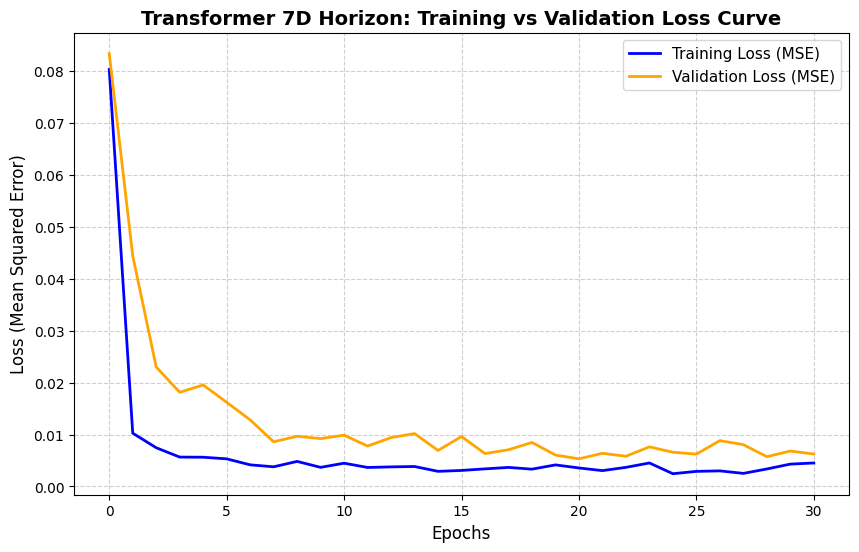

Training process concluded at epoch 31.


In [63]:
plt.figure(figsize=(10, 6))

plt.plot(history_trans_7d.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history_trans_7d.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

plt.title('Transformer 7D Horizon: Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Training process concluded at epoch {len(history_trans_7d.history['loss'])}.")

In [64]:
transformer_7d_preds = transformer_7d.predict(X_test_7d, verbose=0)

y_actual_trans_7d_usd = scaler.inverse_transform(y_test_7d)
preds_trans_7d_usd = scaler.inverse_transform(transformer_7d_preds)

mae_trans_7d = mean_absolute_error(y_actual_trans_7d_usd, preds_trans_7d_usd)
rmse_trans_7d = np.sqrt(mean_squared_error(y_actual_trans_7d_usd, preds_trans_7d_usd))
mape_trans_7d = mean_absolute_percentage_error(y_actual_trans_7d_usd, preds_trans_7d_usd) * 100

print("="*50)
print("        TRANSFORMER 7-DAY HORIZON PERFORMANCE        ")
print("="*50)
print(f"Mean Absolute Error (MAE)      : ${mae_trans_7d:.2f} USD")
print(f"Root Mean Squared Error (RMSE) : ${rmse_trans_7d:.2f} USD")
print(f"Mean Absolute Percentage (MAPE): {mape_trans_7d:.2f}%")
print("="*50)

        TRANSFORMER 7-DAY HORIZON PERFORMANCE        
Mean Absolute Error (MAE)      : $3231.87 USD
Root Mean Squared Error (RMSE) : $4636.04 USD
Mean Absolute Percentage (MAPE): 9.09%


In [65]:
transformer_7d.save('models/transformer_7d_model.keras')

# 3. Save the training history log to disk using pickle
with open('models/histories/transformer_7d_history.pkl', 'wb') as f:
    pickle.dump(history_trans_7d.history, f)

print("Transformer 7D Model and training history saved successfully!")

Transformer 7D Model and training history saved successfully!


In [69]:
# Print out all active variables in memory that contain 'rnn'
print([var for var in globals() if 'rnn' in var.lower()])

['build_rnn_model', 'rnn_1d', 'history_rnn_1d', 'rnn_1d_preds', 'rnn_3d', 'history_rnn_3d', 'rnn_3d_preds', 'rnn_7d', 'history_rnn_7d', 'rnn_7d_preds']


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_actual_rnn_1d_usd = scaler.inverse_transform(y_test_1d)
preds_rnn_1d_usd = scaler.inverse_transform(rnn_1d_preds)

mae_rnn_1d = mean_absolute_error(y_actual_rnn_1d_usd, preds_rnn_1d_usd)
rmse_rnn_1d = np.sqrt(mean_squared_error(y_actual_rnn_1d_usd, preds_rnn_1d_usd))
mape_rnn_1d = mean_absolute_percentage_error(y_actual_rnn_1d_usd, preds_rnn_1d_usd) * 100

y_actual_rnn_3d_usd = scaler.inverse_transform(y_test_3d)
preds_rnn_3d_usd = scaler.inverse_transform(rnn_3d_preds)

mae_rnn_3d = mean_absolute_error(y_actual_rnn_3d_usd, preds_rnn_3d_usd)
rmse_rnn_3d = np.sqrt(mean_squared_error(y_actual_rnn_3d_usd, preds_rnn_3d_usd))
mape_rnn_3d = mean_absolute_percentage_error(y_actual_rnn_3d_usd, preds_rnn_3d_usd) * 100

y_actual_rnn_7d_usd = scaler.inverse_transform(y_test_7d)
preds_rnn_7d_usd = scaler.inverse_transform(rnn_7d_preds)

mae_rnn_7d = mean_absolute_error(y_actual_rnn_7d_usd, preds_rnn_7d_usd)
rmse_rnn_7d = np.sqrt(mean_squared_error(y_actual_rnn_7d_usd, preds_rnn_7d_usd))
mape_rnn_7d = mean_absolute_percentage_error(y_actual_rnn_7d_usd, preds_rnn_7d_usd) * 100

print("Simple RNN metrics successfully generated and restored to active memory!")

Simple RNN metrics successfully generated and restored to active memory!


In [75]:
def safe_get(var_name, default=None):
    return globals().get(var_name, default)

def safe_len(history_obj_name):
    obj = safe_get(history_obj_name)
    if obj is None:
        return 0
    

    if hasattr(obj, 'history'):
        hist_dict = obj.history
    else:
        hist_dict = obj
        
    return len(hist_dict['loss']) if isinstance(hist_dict, dict) and 'loss' in hist_dict else 0

dashboard_data = {
    "Model Architecture": [
        "Simple RNN", "Simple RNN", "Simple RNN",
        "LSTM", "LSTM", "LSTM",
        "1D-CNN", "1D-CNN", "1D-CNN",
        "Transformer", "Transformer", "Transformer"
    ],
    "Forecasting Horizon": [
        "1-Day", "3-Day", "7-Day",
        "1-Day", "3-Day", "7-Day",
        "1-Day", "3-Day", "7-Day",
        "1-Day", "3-Day", "7-Day"
    ],
    "Epochs Executed": [
        safe_len('history_rnn_1d'), safe_len('history_rnn_3d'), safe_len('history_rnn_7d'),
        safe_len('history_lstm_1d'), safe_len('history_lstm_3d'), safe_len('history_lstm_7d'),
        safe_len('history_cnn_1d'), safe_len('history_cnn_3d'), safe_len('history_cnn_7d'),
        safe_len('history_trans_1d'), safe_len('history_trans_3d'), safe_len('history_trans_7d')
    ],
    "MAE (USD)": [
        safe_get('mae_rnn_1d'), safe_get('mae_rnn_3d'), safe_get('mae_rnn_7d'),
        safe_get('mae_lstm_1d'), safe_get('mae_lstm_3d'), safe_get('mae_lstm_7d'),
        safe_get('mae_cnn_1d'), safe_get('mae_cnn_3d'), safe_get('mae_cnn_7d'),
        safe_get('mae_trans_1d'), safe_get('mae_trans_3d'), safe_get('mae_trans_7d')
    ],
    "RMSE (USD)": [
        safe_get('rmse_rnn_1d'), safe_get('rmse_rnn_3d'), safe_get('rmse_rnn_7d'),
        safe_get('rmse_lstm_1d'), safe_get('rmse_lstm_3d'), safe_get('rmse_lstm_7d'),
        safe_get('rmse_cnn_1d'), safe_get('rmse_cnn_3d'), safe_get('rmse_cnn_7d'),
        safe_get('rmse_trans_1d'), safe_get('rmse_trans_3d'), safe_get('rmse_trans_7d')
    ],
    "MAPE (%)": [
        safe_get('mape_rnn_1d'), safe_get('mape_rnn_3d'), safe_get('mape_rnn_7d'),
        safe_get('mape_lstm_1d'), safe_get('mape_lstm_3d'), safe_get('mape_lstm_7d'),
        safe_get('mape_cnn_1d'), safe_get('mape_cnn_3d'), safe_get('mape_cnn_7d'),
        safe_get('mape_trans_1d'), safe_get('mape_trans_3d'), safe_get('mape_trans_7d')
    ]
}

df_dashboard = pd.DataFrame(dashboard_data)

for col in ["MAE (USD)", "RMSE (USD)"]:
    df_dashboard[col] = df_dashboard[col].apply(lambda x: f"${x:,.2f}" if pd.notnull(x) else "Missing")
df_dashboard["MAPE (%)"] = df_dashboard["MAPE (%)"].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else "Missing")

print("="*100)
print("                       MASTER COMPARATIVE ANALYTICS DASHBOARD                        ")
print("="*100)
display(df_dashboard.sort_values(by=["Forecasting Horizon", "MAPE (%)"]))
print("="*100)

                       MASTER COMPARATIVE ANALYTICS DASHBOARD                        


,Model Architecture,Forecasting Horizon,Epochs Executed,MAE (USD),RMSE (USD),MAPE (%)
0,Simple RNN,1-Day,44,$822.73,"$1,232.06",2.40%
3,LSTM,1-Day,50,$862.08,"$1,308.02",2.46%
6,1D-CNN,1-Day,16,"$1,593.65","$2,265.92",4.59%
9,Transformer,1-Day,50,"$2,814.99","$4,160.56",7.87%
4,LSTM,3-Day,50,"$1,112.23","$1,670.67",3.25%
1,Simple RNN,3-Day,18,"$1,169.31","$1,723.09",3.42%
7,1D-CNN,3-Day,43,"$1,392.54","$2,018.39",4.09%
10,Transformer,3-Day,48,"$2,940.29","$3,918.32",8.66%
5,LSTM,7-Day,50,"$1,549.13","$2,328.29",4.53%
2,Simple RNN,7-Day,28,"$1,565.79","$2,360.62",4.54%
